This analysis investigates whether the COVID-19 pandemic led to measurable changes in Conservation values (Security, Conformity, Tradition) and Political Trust in Europe. Using data from the European Social Survey (ESS), we examine three time points: Round 9 (2018) as the pre-pandemic baseline, Round 10 (2020/22) as the pandemic period, and Round 11 (2024) as the post-pandemic landscape.

> **Note on Data:** The dataset uses MRAT-corrected (mean-centered) Schwartz value scores, which remove individual response style bias and allow reliable comparisons across rounds and generations. All three ESS rounds contain complete value data in this version of the dataset.

## Import and Data Load

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sns.set(style="whitegrid")

# Load updated dataset
df = pd.read_csv("ess_final_analysis.csv")
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (136454, 23)


,idno,cntry,essround,generation,yrbrn,agea,gndr,anweight,lrscale,stflife,...,Universalism_centered,Benevolence_centered,Tradition_centered,Security_centered,Conformity_centered,Self-Direction_centered,Stimulation_centered,Hedonism_centered,Achievement_centered,Power_centered
0,27,AT,9,Gen X,1975,43,1.0,0.065890,9,NaN,...,-0.619048,0.047619,0.547619,0.047619,0.047619,0.547619,0.047619,-0.452381,0.047619,0.047619
1,137,AT,9,Boomers,1951,67,1.0,0.124907,5,NaN,...,0.190476,0.690476,-0.309524,0.690476,0.190476,0.190476,-1.309524,0.190476,-0.309524,-0.309524
2,194,AT,9,Gen X,1978,40,2.0,0.685836,5,NaN,...,0.047619,0.547619,0.047619,0.047619,0.547619,0.547619,-0.452381,-0.452381,0.047619,-0.952381
3,220,AT,9,Boomers,1947,71,2.0,0.311789,5,NaN,...,1.095238,0.761905,0.761905,0.761905,1.261905,0.761905,-2.238095,0.261905,-2.238095,-1.738095
4,254,AT,9,Boomers,1954,64,1.0,0.173867,3,NaN,...,1.000000,1.000000,1.000000,0.000000,-0.500000,-0.500000,-1.000000,1.000000,-0.500000,-2.000000


## Method

Two indices are constructed from the MRAT-corrected (mean-centered) Schwartz value scores:

- **Conservation Index**: Captures the degree to which individuals prioritize stability, order, and tradition. Calculated as the mean of `Security_centered`, `Conformity_centered`, and `Tradition_centered`. Higher values indicate a stronger preference for conservation-oriented values.
- **Political Trust Index**: Measures confidence in political institutions. Operationalized via `trstprl` (trust in parliament) on a 0–10 scale.

Statistical significance is assessed using independent samples t-tests (α = 0.05), comparing R9 vs R10 and R9 vs R11 for both indices. Generational cohorts are defined as: Gen Z (born ≥1997), Millennials (1981–1996), Gen X (1965–1980), Boomers (1946–1964), and Silent Gen (born ≤1945).

## Index Construction & Data Quality Check

In [15]:
# 1. Conservation Index from MRAT-corrected (centered) scores
conservation_vars = ['Security_centered', 'Conformity_centered', 'Tradition_centered']
df['Conservation'] = df[conservation_vars].mean(axis=1)

# 2. Political Trust — trstprl only (trstplt and trstlgl not available in this dataset)
df['Political_Trust'] = df['trstprl']

# --- Column Availability by ESS Round ---
key_cols = ['Security_centered', 'Conformity_centered', 'Tradition_centered', 'trstprl', 'mrat_score']
quality_data = {}
for col in key_cols:
    quality_data[col] = {
        f'Round {r}': f"{(1 - df[df['essround'] == r][col].isna().mean()) * 100:.0f}%"
        for r in [9, 10, 11]
    }

quality_df = pd.DataFrame(quality_data).T
print("--- Column Availability by ESS Round ---")
display(quality_df)
print("\n-> All value columns available across all three rounds.")

--- Column Availability by ESS Round ---


,Round 9,Round 10,Round 11
Security_centered,99%,61%,99%
Conformity_centered,99%,61%,99%
Tradition_centered,99%,61%,99%
trstprl,75%,75%,76%
mrat_score,99%,62%,99%



-> All value columns available across all three rounds.


## Statistical Analysis

In [16]:
r9 = df[df['essround'] == 9]
r10 = df[df['essround'] == 10]
r11 = df[df['essround'] == 11]

# --- Summary Statistics ---
print('--- Mean Values by Round ---')
for label, sub in [('R9 (2018)', r9), ('R10 (2020/22)', r10), ('R11 (2024)', r11)]:
    print(f"{label} | Conservation: {sub['Conservation'].mean():.4f} | Political Trust: {sub['Political_Trust'].mean():.4f}")

# --- T-Tests ---
# Conservation
t_cons_r10, p_cons_r10 = ttest_ind(r9['Conservation'], r10['Conservation'], nan_policy='omit')
t_cons_r11, p_cons_r11 = ttest_ind(r9['Conservation'], r11['Conservation'], nan_policy='omit')

# Political Trust
t_trust_r10, p_trust_r10 = ttest_ind(r9['Political_Trust'], r10['Political_Trust'], nan_policy='omit')
t_trust_r11, p_trust_r11 = ttest_ind(r9['Political_Trust'], r11['Political_Trust'], nan_policy='omit')

print('\n--- Statistical Results ---')
print(f"Conservation  R9 vs R10 p-value: {p_cons_r10:.5f} ({'Significant' if p_cons_r10 < 0.05 else 'Insignificant'})")
print(f"Conservation  R9 vs R11 p-value: {p_cons_r11:.5f} ({'Significant' if p_cons_r11 < 0.05 else 'Insignificant'})")
print(f"Political Trust R9 vs R10 p-value: {p_trust_r10:.5f} ({'Significant' if p_trust_r10 < 0.05 else 'Insignificant'})")
print(f"Political Trust R9 vs R11 p-value: {p_trust_r11:.5f} ({'Significant' if p_trust_r11 < 0.05 else 'Insignificant'})")

--- Mean Values by Round ---
R9 (2018) | Conservation: 0.1140 | Political Trust: 4.9867
R10 (2020/22) | Conservation: 0.0771 | Political Trust: 4.6959
R11 (2024) | Conservation: 0.0982 | Political Trust: 4.6460

--- Statistical Results ---
Conservation  R9 vs R10 p-value: 0.00000 (Significant)
Conservation  R9 vs R11 p-value: 0.00018 (Significant)
Political Trust R9 vs R10 p-value: 0.00018 (Significant)
Political Trust R9 vs R11 p-value: 0.00002 (Significant)


The summary statistics and t-tests provide the following insights:

**Conservation Values R9 vs R10 (Pandemic Period, p < 0.001):**
Conservation scores declined from a pre-pandemic mean of 0.114 (R9) to 0.077 (R10) during the pandemic. This shift is statistically significant, yet the direction is counterintuitive: rather than driving Europeans toward greater security-seeking and conformity, the pandemic appears to have slightly loosened conservation-oriented value priorities.

**Conservation Values R9 vs R11 (Long-Term, p < 0.001):**
By 2024, Conservation values partially recover to a mean of 0.098, but remain significantly below the pre-pandemic baseline. This indicates a lasting, if modest, downward shift. The generational breakdown shows a stable hierarchy across all rounds: Silent Gen and Boomers score highest, while Gen Z and Millennials score lowest; a gap that the pandemic did not meaningfully alter.

**Political Trust R9 vs R10 (Pandemic Period, p < 0.001):**
Trust in parliament dropped significantly from a pre-pandemic mean of 4.99 (R9) to 4.70 (R10). This decline is most pronounced among younger generations, particularly Gen Z whose trust fell from 7.57 to 5.59; a drop of nearly two full points on the 0–10 scale.

**Political Trust R9 vs R11 (Long-Term, p < 0.001):**
By 2024, trust does not recover, settling at a mean of 4.65; even slightly below the pandemic-period level. Millennials and Gen X show a steady downward trend across all three rounds, reaching their lowest levels by R11. This pattern suggests that the pandemic functioned as a lasting trust-eroding event rather than a temporary disruption.

## Visualization

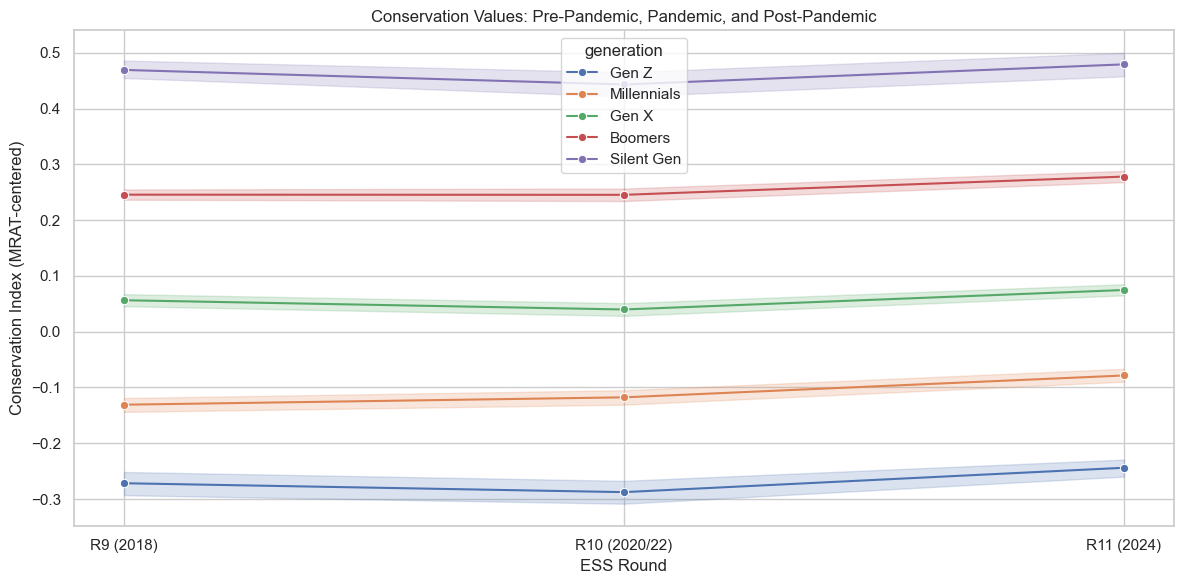

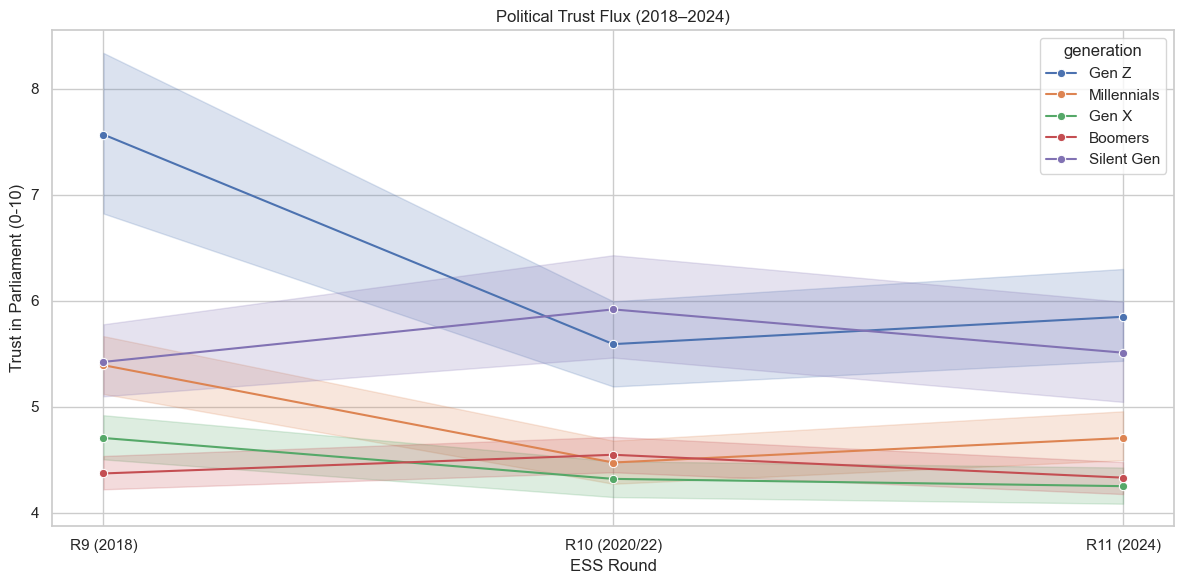

In [17]:
gen_order = ['Gen Z', 'Millennials', 'Gen X', 'Boomers', 'Silent Gen']

# Graph 1: Conservation Trend by Generation (all 3 rounds)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df[df['essround'].isin([9, 10, 11])],
    x='essround', y='Conservation',
    hue='generation', marker='o',
    hue_order=gen_order
)
plt.title("Conservation Values: Pre-Pandemic, Pandemic, and Post-Pandemic")
plt.xticks([9, 10, 11], ['R9 (2018)', 'R10 (2020/22)', 'R11 (2024)'])
plt.ylabel("Conservation Index (MRAT-centered)")
plt.xlabel("ESS Round")
plt.tight_layout()
plt.show()

# Graph 2: Political Trust Trend (all 3 rounds)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df[df['essround'].isin([9, 10, 11])],
    x='essround', y='Political_Trust',
    hue='generation', marker='o',
    hue_order=gen_order
)
plt.title("Political Trust Flux (2018–2024)")
plt.xticks([9, 10, 11], ['R9 (2018)', 'R10 (2020/22)', 'R11 (2024)'])
plt.ylabel("Trust in Parliament (0-10)")
plt.xlabel("ESS Round")
plt.tight_layout()
plt.show()

## Conclusion

This analysis examined whether the COVID-19 pandemic produced measurable and lasting shifts in Conservation values and Political Trust across European generations, using ESS data spanning 2018 to 2024.

**Conservation Values**

The results challenge the intuitive assumption that crises strengthen conservative orientations. Conservation values declined modestly during the pandemic (R9: 0.114 → R10: 0.077) and, while partially recovering by 2024 (R11: 0.098), did not return to pre-pandemic levels. Both comparisons (R9 vs R10 and R9 vs R11) are statistically significant (p < 0.001). The generational hierarchy (Silent Gen and Boomers highest, Gen Z lowest) remains remarkably stable across all three rounds, suggesting that generational value differences are deeply embedded and largely resilient to external shocks.

**Political Trust**

Political trust shows a clear, significant, and sustained decline across the full period (R9: 4.99 → R10: 4.70 → R11: 4.65), with both the pandemic-period and long-term comparisons reaching statistical significance (p < 0.001). The sharpest drop belongs to Gen Z, who entered 2018 with unusually high trust and experienced the steepest decline. Millennials and Gen X follow a steadier but equally persistent downward trend. Together, these findings indicate that the pandemic eroded institutional trust in Europe in a lasting rather than temporary way.